In [92]:
import pandas as pd

First we check to see if the `IUCR`, `Description` and `Primary Type`, `FBI Code` columns are the same.

In [93]:
chicago_crime_df = pd.read_csv('chicago_crime.csv',
                               dtype = {
                                   "ID": "float64",
                                   "Case Number": "string",
                                   "Date": "string",
                                   "Block": "string",
                                   "IUCR": "string",
                                   "Primary Type": "string",
                                   "Description": "string",
                                   "Location Description": "string",
                                   "Arrest": "object",
                                   "Domestic": "object",
                                   "Beat": "float32",
                                   "District": "float32",
                                   "Ward": "float32",
                                   "Community Area": "float32",
                                   "FBI Code": "string",
                                   "X Coordinate": "float32",
                                   "Y Coordinate": "float32",
                                   "Year": "float32",
                                   "Updated On": "string",
                                   "Latitude": "float32",
                                   "Longitude": "float32",
                                   "Location": "string"
                               },
                               low_memory = False
                )

Are `IUCR` and `Description` the same?
Are `Primary Type` and `FBI Code` the same?

In [94]:
print(chicago_crime_df.groupby('IUCR')['Description'].nunique().sum()  == len(chicago_crime_df.groupby('IUCR')['Description'].nunique()))
print(chicago_crime_df.groupby('Primary Type')['FBI Code'].nunique().sum() == len(chicago_crime_df.groupby('Primary Type')['FBI Code'].nunique()))

False
False


In [95]:
chicago_crime_df.groupby('IUCR')['Description'].nunique().reset_index()
chicago_crime_df[
    (chicago_crime_df['IUCR'] == "5121") | (chicago_crime_df['IUCR'] == "5122") | (chicago_crime_df['IUCR'] == "0261")][['IUCR', 'Description']].drop_duplicates()

,IUCR,Description
9630,0261,AGGRAVATED - HANDGUN
115331,5121,ARSONIST - ANNUAL REGISTRATION
285609,5122,ARSONIST - FAIL TO REGISTER NEW ADDRESS
1467014,5121,ARSONIST: ANNUAL REGISTRATION
1497810,0261,AGGRAVATED: HANDGUN
1842688,5122,ARSONIST: FAIL TO REGISTER NEW ADDRESS


`IUCR` and `Description` are the same

In [96]:
chicago_crime_df.groupby('FBI Code')['Primary Type'].nunique()
chicago_crime_df[chicago_crime_df['FBI Code'] == "26"].drop_duplicates().head(3)

,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
4,14160497.0,JK209847,04/08/2026 12:00:00 AM,017XX W DEVON AVE,2826,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,RESIDENCE,false,false,...,40.0,77.0,26,1163295.0,1942550.0,2026.0,04/15/2026 03:43:00 PM,41.998001,-87.674652,"(41.998000526, -87.674648345)"
19,14160328.0,JK209599,04/07/2026 11:13:00 PM,076XX S CLYDE AVE,2825,OTHER OFFENSE,HARASSMENT BY TELEPHONE,RESIDENCE,false,true,...,8.0,43.0,26,1191531.0,1854654.0,2026.0,04/15/2026 03:43:00 PM,41.756168,-87.573639,"(41.756168716, -87.573641687)"
27,14160306.0,JK209560,04/07/2026 10:35:00 PM,0000X W 111TH ST,1330,CRIMINAL TRESPASS,TO LAND,GAS STATION,true,false,...,9.0,49.0,26,1178040.0,1831365.0,2026.0,04/15/2026 03:43:00 PM,41.692577,-87.623787,"(41.692576964, -87.623786349)"


Drop the columns that provide not much information for our models.

In [97]:
df = chicago_crime_df.drop(columns = ['ID', 'Case Number', 'Block', 'Description', 'Ward', 'Updated On', 'Location'])

Check for Null values

In [98]:
df.isna().sum()

Date                         0
IUCR                         0
Primary Type                 0
Location Description     15886
Arrest                       0
Domestic                     0
Beat                         0
District                    47
Community Area          613727
FBI Code                     0
X Coordinate             96353
Y Coordinate             96353
Year                         0
Latitude                 96353
Longitude                96353
dtype: int64

Same number for lat/long and X/Y columns. Maybe same rows?

In [99]:
(df['X Coordinate'].isna() & df['Y Coordinate'].isna() & df['Latitude'].isna() & df['Longitude'].isna()).sum()

df = df[df['X Coordinate'].notna()]

df.isna().sum()

Date                         0
IUCR                         0
Primary Type                 0
Location Description     10384
Arrest                       0
Domestic                     0
Beat                         0
District                    47
Community Area          604523
FBI Code                     0
X Coordinate                 0
Y Coordinate                 0
Year                         0
Latitude                     0
Longitude                    0
dtype: int64

<Axes: >

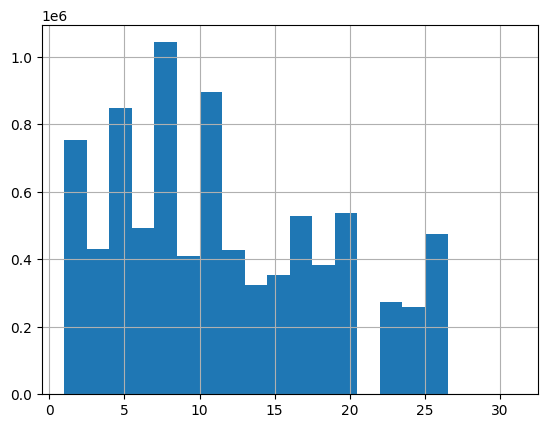

In [100]:
df['District'].hist(bins = 20)

Skewed Distribution. Fill with median.

In [101]:
df['District_missing'] = df['District'].isna().astype(int)
df['District'] = df['District'].fillna(df['District'].median())

In [102]:
df.rename(columns = {'District_missing': "District Missing"}, inplace = True)

df['Location Description Missing'] = df['Location Description'].isna().astype(int)
df['Location Description'] = df['Location Description'].fillna("Unknown")

[Text(0, 0, ''),
 Text(1, 0, ''),
 Text(2, 0, ''),
 Text(3, 0, ''),
 Text(4, 0, ''),
 Text(5, 0, ''),
 Text(6, 0, ''),
 Text(7, 0, ''),
 Text(8, 0, ''),
 Text(9, 0, ''),
 Text(10, 0, ''),
 Text(11, 0, ''),
 Text(12, 0, ''),
 Text(13, 0, ''),
 Text(14, 0, ''),
 Text(15, 0, ''),
 Text(16, 0, ''),
 Text(17, 0, ''),
 Text(18, 0, ''),
 Text(19, 0, ''),
 Text(20, 0, ''),
 Text(21, 0, ''),
 Text(22, 0, ''),
 Text(23, 0, ''),
 Text(24, 0, ''),
 Text(25, 0, ''),
 Text(26, 0, ''),
 Text(27, 0, ''),
 Text(28, 0, ''),
 Text(29, 0, ''),
 Text(30, 0, ''),
 Text(31, 0, ''),
 Text(32, 0, ''),
 Text(33, 0, ''),
 Text(34, 0, ''),
 Text(35, 0, ''),
 Text(36, 0, ''),
 Text(37, 0, ''),
 Text(38, 0, ''),
 Text(39, 0, ''),
 Text(40, 0, ''),
 Text(41, 0, ''),
 Text(42, 0, ''),
 Text(43, 0, ''),
 Text(44, 0, ''),
 Text(45, 0, ''),
 Text(46, 0, ''),
 Text(47, 0, ''),
 Text(48, 0, ''),
 Text(49, 0, ''),
 Text(50, 0, ''),
 Text(51, 0, ''),
 Text(52, 0, ''),
 Text(53, 0, ''),
 Text(54, 0, ''),
 Text(55, 0, ''),
 T

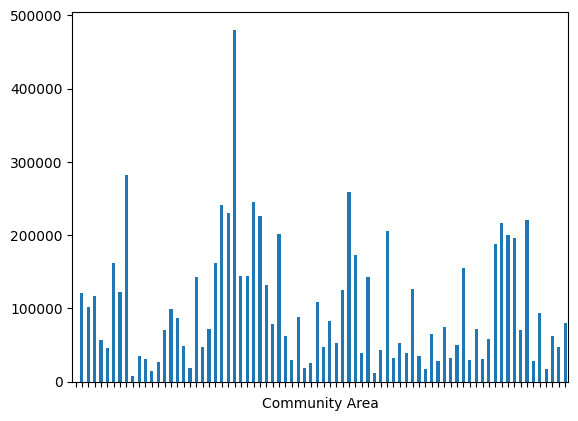

In [103]:
ax = df['Community Area'].value_counts().sort_index().plot.bar()
ax.set_xticklabels([])

In [104]:
df["Community Area Missing"] = df["Community Area"].isna().astype(int)
df["Community Area"] =  df["Community Area"].fillna(df["Community Area"].mode()[0])
df["Community Area"] = df["Community Area"].astype("int16")

Does every row in `Date` column follow the same format?

In [105]:
date_format = pd.to_datetime(df['Date'], format = "%m/%d/%Y %I:%M:%S %p", errors = 'coerce')

In [106]:
date_format.isna().sum()

np.int64(0)

0 missmatch. we make extra columns: `Month`, `Weekday`, `IsWeekend`, `Hour`, `IsNight`.

In [107]:
df['Month'] = date_format.dt.month
df['Weekday'] = date_format.dt.weekday
df['IsWeekend'] = ((df['Weekday'] < 7) & (df['Weekday'] > 4)).astype(int)
df['Hour'] = date_format.dt.hour
df['IsNight'] = ((df['Hour'] > 22) | (df['Hour'] < 6)).astype(int)
df = df.drop(columns = ['Date'])

Next column `IUCR`. Check if all rows are numeric then convert to int

In [108]:
df['IUCR'].str.isnumeric().all()

np.False_

`IUCR` is categorical.

In [109]:
df['IUCR'] = df['IUCR'].astype('category')

Next column: `Primary Type`

In [110]:
df['Primary Type'].unique()

<StringArray>
[                  'CRIMINAL DAMAGE',                           'ASSAULT',
                             'THEFT',                     'OTHER OFFENSE',
               'MOTOR VEHICLE THEFT',                          'BURGLARY',
                           'BATTERY',                           'ROBBERY',
                 'CRIMINAL TRESPASS',                 'WEAPONS VIOLATION',
            'PUBLIC PEACE VIOLATION',           'CRIMINAL SEXUAL ASSAULT',
                'DECEPTIVE PRACTICE',                      'PROSTITUTION',
                         'NARCOTICS',        'OFFENSE INVOLVING CHILDREN',
                       'SEX OFFENSE',                             'ARSON',
                          'HOMICIDE',  'INTERFERENCE WITH PUBLIC OFFICER',
 'CONCEALED CARRY LICENSE VIOLATION',                      'INTIMIDATION',
                          'STALKING',                        'KIDNAPPING',
              'LIQUOR LAW VIOLATION',                  'PUBLIC INDECENCY',
           

Two similar names `CRIM SEXUAL ASSAULT` and `CRIMINAL SEXUAL ASSAULT`. Are they the same?

In [111]:
(set(df[df['Primary Type'] == 'CRIM SEXUAL ASSAULT']['IUCR'].unique()) == 
 set(df[df['Primary Type'] == 'CRIMINAL SEXUAL ASSAULT']['IUCR'].unique()))

True

They are the same

In [112]:
df['Primary Type'] = df['Primary Type'].replace('CRIM SEXUAL ASSAULT', 'CRIMINAL SEXUAL ASSAULT')

Maybe `SEX OFFENSE` and `CRIMINAL SEXUAL ASSAULT` are the same.

In [113]:
(set(df[df['Primary Type'] == 'SEX OFFENSE']['IUCR'].unique()) == set(df[df['Primary Type'] == 'CRIMINAL SEXUAL ASSAULT']['IUCR'].unique()))

False

In [114]:
df['Primary Type'] = df['Primary Type'].astype('category')

Next column `Location Description`

In [115]:
df['Location Description'] = df['Location Description'].astype('category')

Convert categorical to numerical

In [116]:
df['IUCR'] = df['IUCR'].cat.codes
df['Primary Type'] = df['Primary Type'].cat.codes
df['Location Description'] = df['Location Description'].cat.codes

Next column `Arrest`

In [117]:
((df['Arrest'] == 'true') | (df['Arrest'] == 'false')).all()

np.True_

So the values are either `true` or `false`

In [118]:
df['Arrest'] = df['Arrest'].replace({'true': True, 'false': False})
df['Arrest'] = df['Arrest'].astype(bool)

C:\Users\bahre\AppData\Local\Temp\ipykernel_12644\4270701261.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Arrest'] = df['Arrest'].replace({'true': True, 'false': False})


Next column `Domestic`

In [119]:
((df['Domestic'] == 'true') | (df['Domestic'] == 'false')).all()

np.True_

In [120]:
df['Domestic'] = df['Domestic'].replace({'true': True, 'false': False})

C:\Users\bahre\AppData\Local\Temp\ipykernel_12644\1213067583.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Domestic'] = df['Domestic'].replace({'true': True, 'false': False})


Next column `Beat`. Every row **int**? 

In [121]:
(df['Beat'] % 1 != 0).any()

np.False_

In [122]:
df['Beat'] = df['Beat'].astype('int16')

Now same for `District`

In [123]:
df['District'].max()
df['District'].min()
(df['District'] % 1 != 0).any()
df['District'] = df['District'].astype('int16')

`FBI Code`. is **string**. Convert to numerical values.

In [124]:
df['FBI Code'] = df['FBI Code'].astype('category').cat.codes

`X Coordinate` and `Y Coordinate`

In [125]:
((df['X Coordinate'] % 1 != 0) | (df['Y Coordinate'] % 1 != 0)).any()
df['X Coordinate'] = df['X Coordinate'].astype('int32')
df['Y Coordinate'] = df['Y Coordinate'].astype('int32')

Same for `Year` all rows **int**?

In [126]:
(df['Year'] % 1 != 0).any()
df['Year'] = df['Year'].astype('int16')

`Longitude` and `Latitude`

In [127]:
df['Latitude'].dtype

dtype('float32')

Duplicate rows?

In [128]:
df.duplicated().any()
df.duplicated().sum()
df.value_counts().max()

np.int64(63)

In [129]:
df.drop_duplicates()

,IUCR,Primary Type,Location Description,Arrest,Domestic,Beat,District,Community Area,FBI Code,X Coordinate,...,Latitude,Longitude,District Missing,Location Description Missing,Community Area Missing,Month,Weekday,IsWeekend,Hour,IsNight
0,171,5,148,False,False,123,1,32,16,1176935,...,41.869736,-87.625885,0,0,0,4,2,0,0,1
1,81,1,15,False,False,1923,19,6,9,1167312,...,41.947731,-87.660400,0,0,0,4,2,0,0,1
2,100,31,86,True,False,612,6,71,7,1169539,...,41.750492,-87.654305,0,0,0,4,2,0,0,1
3,81,1,185,False,True,723,7,68,9,1170750,...,41.777256,-87.649582,0,0,0,4,2,0,0,1
4,333,23,161,False,False,2433,24,77,25,1163295,...,41.998001,-87.674652,0,0,0,4,2,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8532618,270,21,161,True,False,911,9,25,2,1160226,...,41.797756,-87.687958,0,0,1,1,0,0,0,1
8532619,95,31,17,False,False,1431,14,22,7,1157520,...,41.923756,-87.696632,0,0,0,1,0,0,0,1
8532620,95,31,161,False,False,1132,11,26,7,1147877,...,41.874374,-87.732529,0,0,0,1,0,0,0,1
8532621,95,31,161,False,False,714,7,25,7,1165053,...,41.780140,-87.670441,0,0,1,1,0,0,0,1


## Outliers
The approximate Longitude rage for chicago is between $87.94\degree W$ and $87.56\degree W$

In [130]:
# Check the rows
df[((df['Longitude'] < -88) | (df['Longitude'] > -86))][['Longitude', 'Latitude']]

# Drop the rows
df = df[((df['Longitude'] > -88) & (df['Longitude'] < -86))]

Latitude range is between $42.02\degree N$ and $41.64\degree N$

In [131]:
((df['Latitude'] > 43) | (df['Latitude'] < 40)).sum()

np.int64(0)

X and Y coordinates.

In [132]:
((df['X Coordinate'] > 1205000) | (df['X Coordinate'] < 1085000)).sum()
# Drop outliers
df = df[((df['X Coordinate'] < 1205000) & (df['X Coordinate'] > 1085000))]

In [133]:
((df['Y Coordinate'] > 1955000) | (df['Y Coordinate'] < 1805000)).sum()

np.int64(0)

No outliers. Check `Primary Type` again.

In [134]:
df['Primary Type'].value_counts().sort_values()

Primary Type
9           1
27         23
19         26
12        126
22        161
25        228
20        922
4        1738
14       5150
30       6302
15       7481
11      14139
0       14478
10      14568
16      15336
13      20585
29      32713
6       36866
26      54981
21      56740
24      69812
32     126349
7      228126
28     315126
8      373042
17     435619
3      449097
23     528151
1      571148
18     753949
5      964945
2     1547134
31    1790740
Name: count, dtype: int64

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8435802 entries, 0 to 8532622
Data columns (total 22 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   IUCR                          int16  
 1   Primary Type                  int8   
 2   Location Description          int16  
 3   Arrest                        bool   
 4   Domestic                      bool   
 5   Beat                          int16  
 6   District                      int16  
 7   Community Area                int16  
 8   FBI Code                      int8   
 9   X Coordinate                  int32  
 10  Y Coordinate                  int32  
 11  Year                          int16  
 12  Latitude                      float32
 13  Longitude                     float32
 14  District Missing              int64  
 15  Location Description Missing  int64  
 16  Community Area Missing        int64  
 17  Month                         int32  
 18  Weekday                    